In [14]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow.keras import layers, Model, Input


In [ ]:
artists = pd.read_csv("artists.dat", sep="\t", encoding="latin-1")
user_artists = pd.read_csv("user_artists.dat", sep="\t", encoding="latin-1")
tags = pd.read_csv("tags.dat", sep="\t", encoding="latin-1")


In [16]:
artists.head()
user_artists.head()


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


Create User–Artist Matrix

In [17]:
user_artist_matrix = user_artists.pivot_table(
    index='userID',
    columns='artistID',
    values='weight',
    fill_value=0
)


Normalize Data

In [18]:
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(user_artist_matrix)


Collaborative Filtering (SVD)

In [19]:
svd = TruncatedSVD(n_components=50)
matrix_reduced = svd.fit_transform(matrix_scaled)


In [20]:
user_similarity = cosine_similarity(matrix_reduced)


Basic Recommendation Function

In [21]:
def recommend_cf(user_id, top_n=5):
    idx = list(user_artist_matrix.index).index(user_id)

    sim_users = np.argsort(user_similarity[idx])[-6:-1]

    recs = user_artist_matrix.iloc[sim_users].mean(axis=0)
    top_artists = recs.sort_values(ascending=False).head(top_n).index

    return artists[artists['id'].isin(top_artists)][['id','name']]


In [22]:
recommend_cf(2)


,id,name
45,51,Duran Duran
66,72,Depeche Mode
153,159,The Cure
505,511,U2
984,993,Simple Minds


Clustering Artists (Find Similar Vibes)

In [23]:
artist_features = user_artist_matrix.T


In [24]:
kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(artist_features)

artists['cluster'] = clusters


Deep Learning Autoencoder

In [25]:
input_dim = matrix_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

x = layers.Dense(128, activation='relu')(input_layer)
x = layers.Dense(64, activation='relu')(x)
encoded = layers.Dense(32, activation='relu')(x)

x = layers.Dense(64, activation='relu')(encoded)
x = layers.Dense(128, activation='relu')(x)
decoded = layers.Dense(input_dim)(x)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    matrix_scaled,
    matrix_scaled,
    epochs=10,
    batch_size=256
)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 1.0006
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.0000
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9995
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9984
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9956
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.9905
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9836
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9759
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.9674
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.9585


Extract Embeddings

In [26]:
encoder = Model(inputs=input_layer, outputs=encoded)
embeddings = encoder.predict(matrix_scaled)


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


DL Recommendation Function

In [27]:
sim = cosine_similarity(embeddings)

def recommend_dl(user_id, top_n=5):
    idx = list(user_artist_matrix.index).index(user_id)

    sim_users = np.argsort(sim[idx])[-6:-1]

    recs = user_artist_matrix.iloc[sim_users].mean(axis=0)
    top_artists = recs.sort_values(ascending=False).head(top_n).index

    return artists[artists['id'].isin(top_artists)][['id','name']]


In [28]:
recommend_dl(2)


,id,name
49,55,Kylie Minogue
61,67,Madonna
66,72,Depeche Mode
83,89,Lady Gaga
1424,1433,Daddy Yankee


In [29]:
print(artists.shape)
print(user_artists.shape)
print(user_artist_matrix.shape)


(17632, 5)
(92834, 3)
(1892, 17632)


In [30]:
artists.head()
user_artists.head()


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [31]:
print(user_artist_matrix.index[:10])


Index([2, 3, 4, 5, 6, 7, 8, 9, 10, 11], dtype='int64', name='userID')


In [33]:
recommend_cf(20)


,id,name
597,603,Aphex Twin
735,744,Autechre
763,772,Proem
1736,1745,Apparat
2652,2672,Clark


In [34]:
recommend_dl(2)


,id,name
49,55,Kylie Minogue
61,67,Madonna
66,72,Depeche Mode
83,89,Lady Gaga
1424,1433,Daddy Yankee


In [35]:
recommend_cf(3)
recommend_cf(10)
recommend_cf(50)


,id,name
59,65,Coldplay
66,72,Depeche Mode
148,154,Radiohead
184,190,Muse
527,533,Oasis


In [36]:
print(user_similarity[0][:10])


[ 1.          0.02019013  0.46724165  0.09446726  0.01307108 -0.087361
  0.00493856 -0.09923695  0.13464681 -0.08265238]


In [37]:
user_artist_matrix.loc[2].sort_values(ascending=False).head(10)


artistID
51    13883.0
52    11690.0
53    11351.0
54    10300.0
55     8983.0
56     6152.0
57     5955.0
58     4616.0
59     4337.0
60     4147.0
Name: 2, dtype: float64

C:\Users\Ved Dhanokar\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


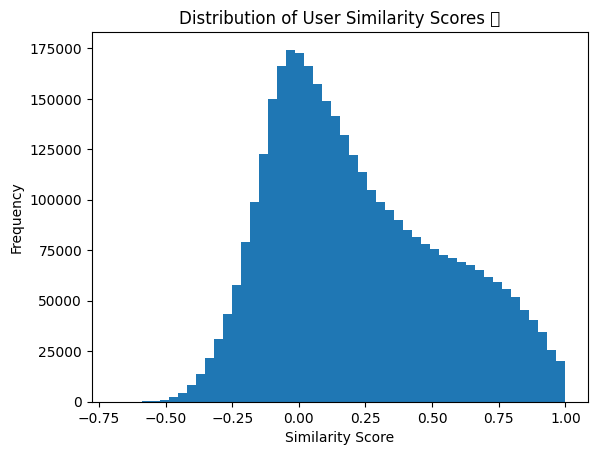

In [40]:
import matplotlib.pyplot as plt

plt.hist(user_similarity.flatten(), bins=50)

plt.title("Distribution of User Similarity Scores 🎧")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.show()
